In [ ]:
import pandas as pd
import numpy as np

# Load dataset
data = pd.read_excel(r"Conf_Text_Labels.xlsx")

# Entropy function
def entropy(target):

    values, counts = np.unique(target, return_counts=True)

    prob = counts / counts.sum()

    entropy_value = -np.sum(prob * np.log2(prob))

    return entropy_value


print("Entropy:", entropy(data['Conf Label']))

Entropy: 2.465388857650649


In [8]:
import pandas as pd
import numpy as np

# Load dataset
data = pd.read_excel(r"Conf_Text_Labels.xlsx")

def gini_index(target):

    values, counts = np.unique(target, return_counts=True)

    prob = counts / counts.sum()

    gini = 1 - np.sum(prob ** 2)

    return gini


print("Gini Index:", gini_index(data['Conf Label']))

Gini Index: 0.8104243403603404


In [7]:
import pandas as pd
import numpy as np

data = pd.read_excel(r"Conf_Text_Labels.xlsx")

data['Text_Length'] = data['Text'].astype(str).apply(len)

def entropy(target):
    values, counts = np.unique(target, return_counts=True)
    prob = counts / counts.sum()
    return -np.sum(prob * np.log2(prob))

def information_gain(data, feature, target):
    total_entropy = entropy(data[target])
    values, counts = np.unique(data[feature], return_counts=True)

    weighted_entropy = 0
    for v, c in zip(values, counts):
        subset = data[data[feature] == v]
        weighted_entropy += (c/len(data)) * entropy(subset[target])

    return total_entropy - weighted_entropy

gain = information_gain(data, 'Text_Length', 'Conf Label')
print("Information Gain:", gain)

Information Gain: 0.6370966146571921


In [6]:
import pandas as pd

data = pd.read_excel(r"Conf_Text_Labels.xlsx")

data['Text_Length'] = data['Text'].astype(str).apply(len)

def equal_width_binning(column, bins=4):
    min_val = column.min()
    max_val = column.max()
    width = (max_val - min_val) / bins
    return ((column - min_val) // width).astype(int)

data['Text_Length_Binned'] = equal_width_binning(data['Text_Length'],4)

print(data[['Text_Length','Text_Length_Binned']].head())

   Text_Length  Text_Length_Binned
0           14                   0
1           28                   0
2           25                   0
3            5                   0
4           44                   0


In [5]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

# Load dataset
data = pd.read_excel(r"Conf_Text_Labels.xlsx")

# Remove rows where Conf Label is empty
data = data.dropna(subset=['Conf Label'])

# Convert text to numeric feature
data['Text_Length'] = data['Text'].astype(str).apply(len)

# Features and target
X = data[['Text_Length']]
y = data['Conf Label']

# Train model
model = DecisionTreeClassifier()
model.fit(X, y)

print("Decision Tree Model Built Successfully")

Decision Tree Model Built Successfully


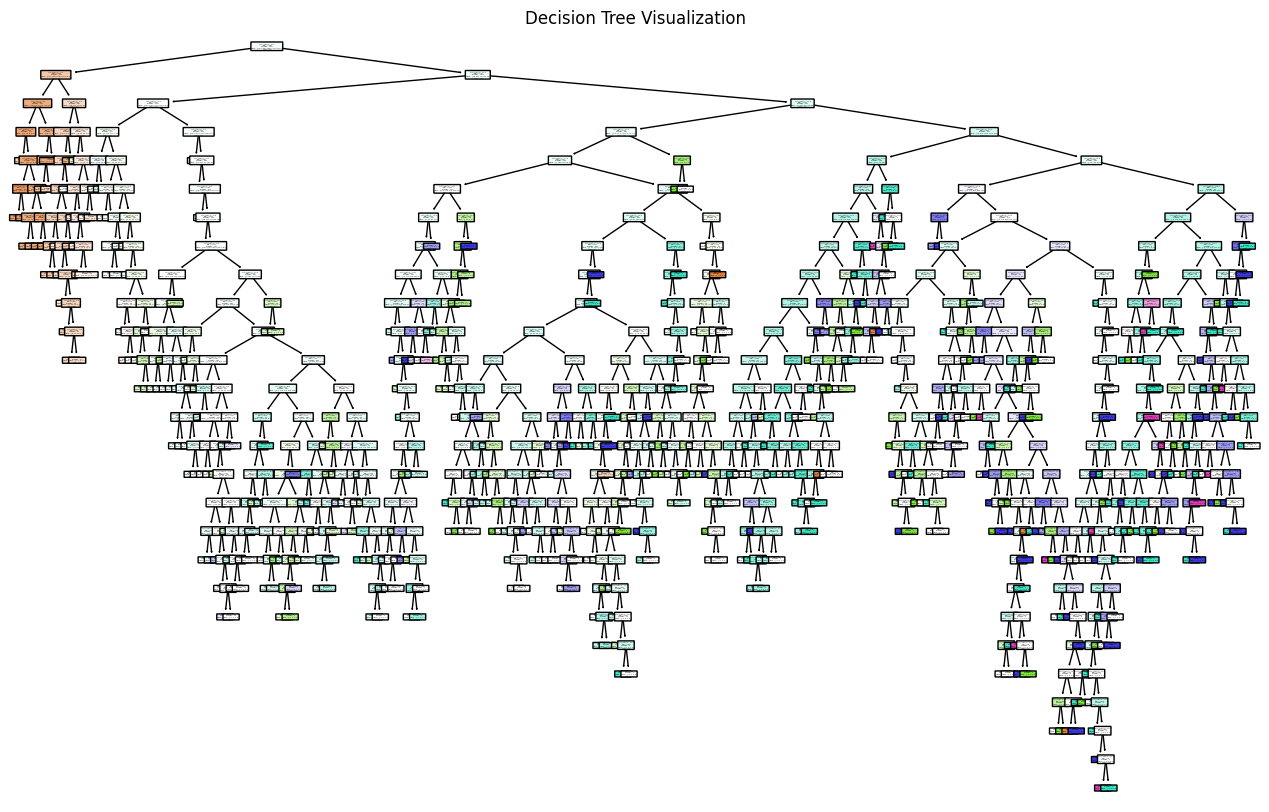

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

data = pd.read_excel(r"Conf_Text_Labels.xlsx")

data = data.dropna(subset=['Conf Label'])

# Convert label to numeric
data['Conf Label'] = pd.to_numeric(data['Conf Label'], errors='coerce')

# Remove rows again if conversion created NaN
data = data.dropna(subset=['Conf Label'])

# Convert text column into numeric feature
data['Text_Length'] = data['Text'].astype(str).apply(len)

# Define features and target
X = data[['Text_Length']]
y = data['Conf Label']

# Train Decision Tree
model = DecisionTreeClassifier()
model.fit(X, y)

# Plot the Decision Tree
plt.figure(figsize=(16,10))

plot_tree(
    model,
    feature_names=['Text_Length'],
    class_names=True,
    filled=True,
    rounded=True
)

plt.title("Decision Tree Visualization")

plt.show()

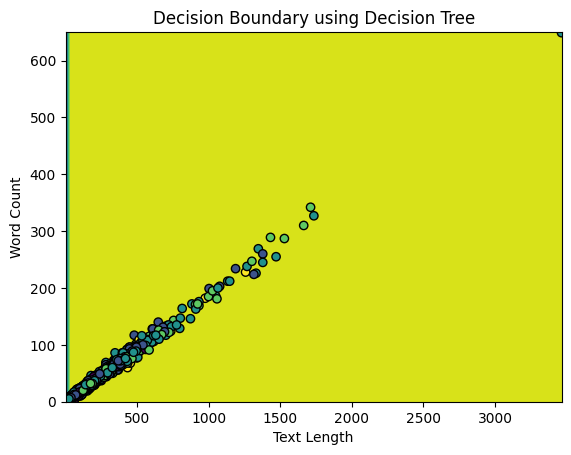

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay

data = pd.read_excel(r"Conf_Text_Labels.xlsx")
data = data.dropna(subset=['Conf Label'])

# Convert Conf Label to numeric
data['Conf Label'] = pd.to_numeric(data['Conf Label'], errors='coerce')
data = data.dropna(subset=['Conf Label'])

# Create two features from text
data['Text_Length'] = data['Text'].astype(str).apply(len)
data['Word_Count'] = data['Text'].astype(str).apply(lambda x: len(x.split()))

# Select two features
X = data[['Text_Length', 'Word_Count']]
y = data['Conf Label']

# Train Decision Tree
model = DecisionTreeClassifier(max_depth=4)
model.fit(X, y)

# Plot decision boundary
DecisionBoundaryDisplay.from_estimator(
    model,
    X,
    response_method="predict",
    xlabel="Text Length",
    ylabel="Word Count"
)

plt.scatter(
    X['Text_Length'],
    X['Word_Count'],
    c=y,
    cmap='viridis',
    edgecolor='black'
)

plt.title("Decision Boundary using Decision Tree")
plt.show()